In [2]:
pip install imbalanced-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

df=pd.read_csv('creditcard.csv')

In [4]:
print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
!pip install deap




[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from deap import base, creator, tools, algorithms
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [7]:
import pandas as pd
import numpy as np
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split

# Load and prepare the dataset
X = df.drop(columns=['Time', 'Amount', 'Class'])  # Drop unneeded columns
y = df['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE-Tomek to the training data
smote_tomek = SMOTETomek(sampling_strategy='minority', random_state=42)
X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train, y_train)

# Verify the class distribution after resampling
print("Original dataset class distribution:", dict(zip(*np.unique(y_train, return_counts=True))))
print("Resampled dataset class distribution:", dict(zip(*np.unique(y_train_balanced, return_counts=True))))


Original dataset class distribution: {0: 199020, 1: 344}
Resampled dataset class distribution: {0: 199020, 1: 199020}


In [8]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from deap import base, creator, tools, algorithms
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Assuming X_train_balanced and y_train_balanced are already defined from SMOTE

# Define the Genetic Algorithm components
if 'FitnessMax' not in creator.__dict__:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))
if 'Individual' not in creator.__dict__:
    creator.create("Individual", list, fitness=creator.FitnessMax)

def create_individual():
    return creator.Individual(np.random.randint(0, 2, X_train_balanced.shape[1]))

def eval_individual(individual):
    selected_features = [index for index in range(len(individual)) if individual[index] == 1]
    if len(selected_features) == 0:
        return 0,  # Prevent division by zero

    # Convert DataFrames to NumPy arrays for indexing
    X_train_array = X_train_balanced.to_numpy()
    X_test_array = X_test.to_numpy()

    # Select features based on the individual's binary encoding
    X_train_selected = X_train_array[:, selected_features]
    X_test_selected = X_test_array[:, selected_features]

    model = XGBClassifier(eval_metric='logloss', tree_method='hist', device='cuda')
    model.fit(X_train_selected, y_train_balanced)
    predictions = model.predict(X_test_selected)
    return accuracy_score(y_test, predictions),


toolbox = base.Toolbox()
toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.05)
toolbox.register("select", tools.selTournament, tournsize=3)
toolbox.register("evaluate", eval_individual)

# GA parameters
population = toolbox.population(n=50)
ngen = 100
cxpb = 0.5
mutpb = 0.05

# Running GA
population, logbook = algorithms.eaSimple(population, toolbox, cxpb=cxpb, mutpb=mutpb, ngen=ngen, verbose=True)

# Get the best individual
best_individual = tools.selBest(population, k=1)[0]
selected_features = [index for index in range(len(best_individual)) if best_individual[index] == 1]

print("Best individual: ", best_individual)
print("Selected features (indices): ", selected_features)

C:\Users\VEDANT WADE\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:11:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


gen	nevals
0  	50    
1  	23    
2  	21    
3  	32    
4  	31    
5  	24    
6  	30    
7  	23    
8  	24    
9  	22    
10 	28    
11 	35    
12 	23    
13 	18    
14 	33    
15 	28    
16 	32    
17 	31    
18 	32    
19 	25    
20 	22    
21 	25    
22 	26    
23 	30    
24 	28    
25 	34    
26 	30    
27 	31    
28 	23    
29 	25    
30 	22    
31 	24    
32 	24    
33 	36    
34 	26    
35 	22    
36 	28    
37 	23    
38 	25    
39 	25    
40 	26    
41 	32    
42 	22    
43 	31    
44 	22    
45 	30    
46 	23    
47 	17    
48 	38    
49 	21    
50 	29    
51 	30    
52 	20    
53 	38    
54 	25    
55 	20    
56 	16    
57 	26    
58 	34    
59 	36    
60 	31    
61 	29    
62 	30    
63 	28    
64 	26    
65 	33    
66 	27    
67 	27    
68 	22    
69 	23    
70 	22    
71 	21    
72 	29    
73 	33    
74 	23    
75 	24    
76 	26    
77 	25    
78 	28    
79 	32    
80 	16    
81 	23    
82 	35    
83 	22    
84 	29    
85 	24    
86 	30    
87 	26    
88 	12    
89 	25    

C:\Users\VEDANT WADE\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:20:53] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\VEDANT WADE\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:20:55] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\VEDANT WADE\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:20:57] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0015a694724fa8361-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_la

F1 Score: 0.8151
Accuracy: 0.9994
Precision: 0.9231
Recall: 0.7297
ROC AUC Score: 0.8648
Confusion Matrix:
[[85286     9]
 [   40   108]]


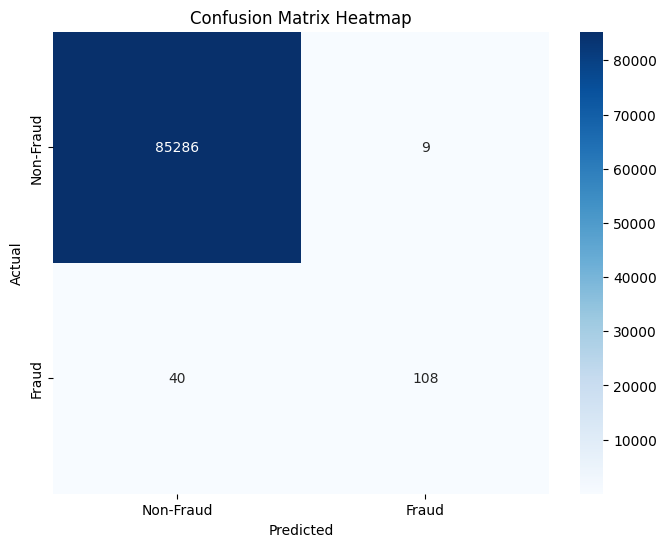

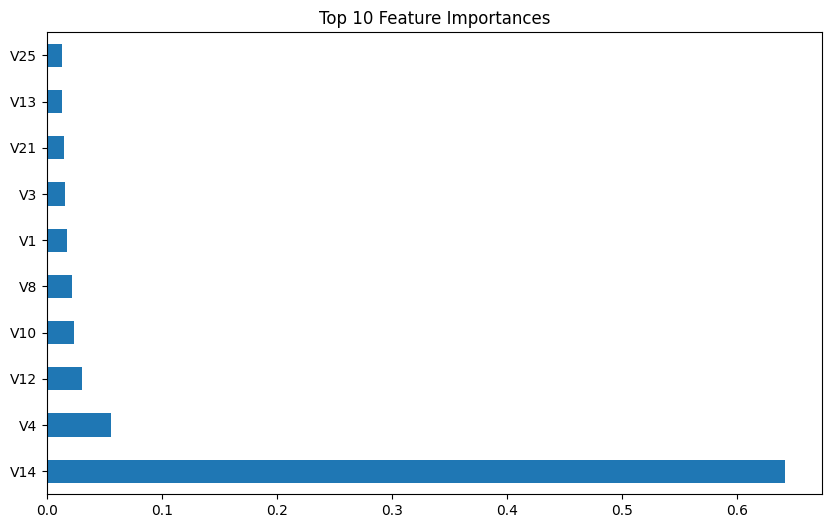

In [11]:
import pandas as pd
import numpy as np
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming 'df' is your dataset and 'selected_features' is the list of features selected by the GA
X = df.drop(columns=['Time', 'Amount', 'Class'])  # Drop unneeded columns
y = df['Class']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Apply SMOTE-Tomek to the training data
smote_tomek = SMOTETomek(sampling_strategy='minority', random_state=42)
X_train_balanced, y_train_balanced = smote_tomek.fit_resample(X_train, y_train)

# Ensure that X_train_balanced has the same columns as X_test
X_train_balanced = pd.DataFrame(X_train_balanced, columns=X_train.columns)

# Standardize the data (fit on training data, transform both train and test)
scaler = StandardScaler()
X_train_balanced_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

# Now X_train_balanced_scaled and X_test_scaled should have the same structure and can be used for model training


# Base learners for stacking
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('xgb', XGBClassifier(eval_metric='logloss', tree_method='hist', use_label_encoder=False, random_state=42))
]

# Stacking model
stack_model = StackingClassifier(estimators=base_learners, final_estimator=RandomForestClassifier(), cv=5)

# Hyperparameter tuning for XGBoost
param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss', tree_method='hist', use_label_encoder=False), param_grid_xgb, cv=5, scoring='f1')
grid_xgb.fit(X_train_balanced, y_train_balanced)

# Best XGBoost model
best_xgb = grid_xgb.best_estimator_

# Train the stacking model with the best XGBoost
stack_model.fit(X_train_balanced, y_train_balanced)

# Make predictions with stacking
y_pred_stack = stack_model.predict(X_test)

# Adjust decision threshold for better precision-recall tradeoff
y_pred_proba = stack_model.predict_proba(X_test)[:, 1]
threshold = 0.4  # Adjust threshold here based on performance
y_pred_adjusted = (y_pred_proba >= threshold).astype(int)

# Calculate evaluation metrics
f1 = f1_score(y_test, y_pred_adjusted)
accuracy = accuracy_score(y_test, y_pred_adjusted)
precision = precision_score(y_test, y_pred_adjusted)
recall = recall_score(y_test, y_pred_adjusted)
roc_auc = roc_auc_score(y_test, y_pred_adjusted)
conf_matrix = confusion_matrix(y_test, y_pred_adjusted)

# Print the evaluation metrics
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Visualize the Confusion Matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Fraud', 'Fraud'], yticklabels=['Non-Fraud', 'Fraud'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

# Feature Importance Plot (from the best XGBoost model)
plt.figure(figsize=(10, 6))
feature_importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
feature_importances.nlargest(10).plot(kind='barh')
plt.title('Top 10 Feature Importances')
plt.show()
